# FNN Audit on the Full PPG Dataset

Notebook này triển khai thiết kế trong `STEP3B_FNN_AUDIT.md`.
FNN được tính độc lập trên từng cửa sổ và từng dạng dữ liệu; kết quả 60, 120
và 180 giây được lưu riêng trước khi tổng hợp ở cấp cửa sổ và cấp phiên.

Cấu hình chính:

- `R_tol = 15`, `A_tol = 2`, ngưỡng FNN `1%`, `max_m = 10`;
- Raw dùng độ trễ vật lý `0,20 giây`;
- Processed dùng độ trễ vật lý `0,16 giây`;
- chỉ dùng cửa sổ đạt quasi-stationarity của dạng dữ liệu tương ứng.


In [1]:
from pathlib import Path
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import spearmanr


def find_project_root():
    "Return the repository root."
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "phase1" / "src").is_dir():
            return candidate
    raise FileNotFoundError("Cannot locate the repository root.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "phase1" / "src"
DATA_DIR = PROJECT_ROOT / "phase1" / "segmentated_data" / "dhdata"
OUTPUT_DIR = PROJECT_ROOT / "phase1" / "results" / "fnn"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / "_cache"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataloader.loader import get_data
from embedding.fnn import false_nearest_neighbors

WINDOW_SIZES = (60, 120, 180)
STATES = {0: "Awake", 1: "Drowsy"}
REPRESENTATIONS = ("raw", "processed")
TAU_SECONDS = {"raw": 0.20, "processed": 0.16}
R_TOL = 15.0
A_TOL = 2.0
FNN_THRESHOLD = 1.0
MAX_M = 10
THEILER = 0
FORCE_RECOMPUTE = False

R_TOL_VALUES = (10.0, 15.0, 20.0)
A_TOL_VALUES = (1.5, 2.0, 2.5)
THRESHOLD_VALUES = (0.5, 1.0, 2.0)
THEILER_MULTIPLIERS = (0, 1, 2)

INDEX_PATH = DATA_DIR / "segments_index.csv"
WINDOW_RESULTS_PATH = OUTPUT_DIR / "fnn_window_results.csv"
SESSION_SUMMARY_PATH = OUTPUT_DIR / "fnn_session_summary.csv"
CURVE_RESULTS_PATH = OUTPUT_DIR / "fnn_curves.csv"
SENSITIVITY_RESULTS_PATH = OUTPUT_DIR / "fnn_sensitivity_results.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Hàm dùng chung

Các hàm dưới đây giữ nguyên định danh cửa sổ, dùng đúng độ trễ theo dạng dữ
liệu và không thay `selected_m=None` bằng `max_m`.


In [2]:
RESULT_COLUMNS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
    "fs",
    "tau_samples",
    "max_m",
    "selected_m",
    "min_fnn_percent",
    "valid_count_at_selected_m",
    "m_found",
]
CURVE_COLUMNS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
    "dimension",
    "fnn_percent",
    "valid_count",
]


def natural_key(value):
    "Return a natural-sort key."
    parts = re.split(r"(\d+)", str(value))
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def parse_boolean(series):
    "Return a validated Boolean series."
    if pd.api.types.is_bool_dtype(series):
        return series
    values = series.astype(str).str.strip().str.lower()
    result = values.map({"true": True, "false": False})
    if result.isna().any():
        raise ValueError("Boolean column contains invalid values.")
    return result.astype(bool)


def tau_in_samples(representation, fs):
    "Convert the fixed physical delay to samples."
    key = representation.lower()
    return int(round(TAU_SECONDS[key] * fs))


def selected_from_curve(dims, percentages, threshold):
    "Select the first dimension below a threshold."
    candidates = np.flatnonzero(percentages <= threshold)
    if candidates.size == 0:
        return None
    return int(dims[candidates[0]])


def analyze_signal(signal, tau, **overrides):
    "Run the FNN core with the primary configuration."
    parameters = {
        "max_m": MAX_M,
        "r_tol": R_TOL,
        "a_tol": A_TOL,
        "theiler": THEILER,
        "fnn_threshold": FNN_THRESHOLD,
    }
    parameters.update(overrides)
    return false_nearest_neighbors(signal, tau=tau, **parameters)


def size_result_path(window_size):
    "Return the window-level result path for one size."
    return CACHE_DIR / f"fnn_{window_size}_results.csv"


def size_curve_path(window_size):
    "Return the curve result path for one size."
    return CACHE_DIR / f"fnn_{window_size}_curves.csv"


def expected_count(index, window_size):
    "Return the expected rows for one window size."
    subset = index[index["window_size_s"] == window_size]
    raw = int(subset["stationarity_pass_raw"].sum())
    processed = int(subset["stationarity_pass_processed"].sum())
    return raw + processed


def cache_is_complete(path, expected_rows, window_size):
    "Check a cached window-level result."
    if not path.is_file():
        return False
    cached = pd.read_csv(path)
    required = set(RESULT_COLUMNS)
    if not required.issubset(cached.columns):
        return False
    if len(cached) != expected_rows:
        return False
    return (
        cached["window_size_s"].eq(window_size).all()
        and cached["max_m"].eq(MAX_M).all()
    )


def summarize_one_signal(row, signal):
    "Return one result row and its FNN curve."
    tau = tau_in_samples(row["representation"], row["fs"])
    try:
        dims, percentages, counts, selected_m = analyze_signal(
            signal,
            tau,
        )
    except (TypeError, ValueError) as exc:
        context = (
            f"{row['session']} | {row['window_size_s']} s | "
            f"{row['label']} | {row['representation']} | "
            f"window {row['window_id']}"
        )
        raise RuntimeError(f"FNN failed for {context}: {exc}") from exc

    selected_index = np.flatnonzero(dims == selected_m)
    valid_at_selected = (
        int(counts[selected_index[0]])
        if selected_index.size
        else np.nan
    )
    result = {
        **row,
        "tau_samples": tau,
        "max_m": MAX_M,
        "selected_m": selected_m,
        "min_fnn_percent": float(percentages.min()),
        "valid_count_at_selected_m": valid_at_selected,
        "m_found": selected_m is not None,
    }
    curve = pd.DataFrame({
        **{
            key: [row[key]] * len(dims)
            for key in (
                "session",
                "window_id",
                "window_size_s",
                "label",
                "representation",
            )
        },
        "dimension": dims,
        "fnn_percent": percentages,
        "valid_count": counts,
    })
    return result, curve


def run_window_size(window_size, index, sessions):
    "Run and save FNN for every eligible window of one size."
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    records = []
    curves = []
    for number, session in enumerate(sessions, start=1):
        for representation in REPRESENTATIONS:
            awake, drowsy = get_data(
                session,
                data_dir=DATA_DIR,
                window_sizes=window_size,
                stationarity=representation,
            )
            state_batches = {"Awake": awake, "Drowsy": drowsy}
            for label, state_data in state_batches.items():
                batch = state_data[window_size]
                for array_index, signal in enumerate(
                    batch[representation]
                ):
                    row = {
                        "session": session,
                        "window_id": int(
                            batch["window_id"][array_index]
                        ),
                        "window_size_s": window_size,
                        "label": label,
                        "representation": representation.title(),
                        "fs": float(batch["fs"]),
                    }
                    result, curve = summarize_one_signal(row, signal)
                    records.append(result)
                    curves.append(curve)

        checkpoint = pd.DataFrame(records, columns=RESULT_COLUMNS)
        checkpoint.to_csv(size_result_path(window_size), index=False)
        print(
            f"{window_size} s | {number:02d}/{len(sessions)} | "
            f"{session}"
        )

    results = pd.DataFrame(records, columns=RESULT_COLUMNS)
    curve_results = pd.concat(curves, ignore_index=True)
    results.to_csv(size_result_path(window_size), index=False)
    curve_results.to_csv(size_curve_path(window_size), index=False)
    return results, curve_results


def load_aggregate_window_size(window_size, expected_rows):
    "Load one size from the aggregate result files."
    if not WINDOW_RESULTS_PATH.is_file() or not CURVE_RESULTS_PATH.is_file():
        return None

    results = pd.read_csv(WINDOW_RESULTS_PATH)
    results = results[results["window_size_s"] == window_size].copy()
    curves = pd.read_csv(CURVE_RESULTS_PATH)
    curves = curves[curves["window_size_s"] == window_size].copy()
    complete = (
        len(results) == expected_rows
        and len(curves) == expected_rows * MAX_M
        and results["max_m"].eq(MAX_M).all()
    )
    if not complete:
        return None

    results["m_found"] = parse_boolean(results["m_found"])
    print(f"Loaded aggregate results: {window_size} s")
    return results, curves


def load_or_run_window_size(window_size, index, sessions):
    "Load valid results or run one window-size experiment."
    expected_rows = expected_count(index, window_size)
    if not FORCE_RECOMPUTE:
        aggregate = load_aggregate_window_size(
            window_size,
            expected_rows,
        )
        if aggregate is not None:
            return aggregate

    result_path = size_result_path(window_size)
    curve_path = size_curve_path(window_size)
    complete = cache_is_complete(
        result_path,
        expected_rows,
        window_size,
    )
    if FORCE_RECOMPUTE or not complete or not curve_path.is_file():
        return run_window_size(window_size, index, sessions)

    results = pd.read_csv(result_path)
    results["m_found"] = parse_boolean(results["m_found"])
    curves = pd.read_csv(curve_path)
    print(f"Loaded temporary cache: {result_path.name}")
    return results, curves


def iqr(values):
    "Return the interquartile range."
    values = pd.Series(values).dropna()
    if values.empty:
        return np.nan
    return values.quantile(0.75) - values.quantile(0.25)


def first_mode(values):
    "Return the smallest mode or NaN."
    modes = pd.Series(values).dropna().mode()
    return np.nan if modes.empty else float(modes.iloc[0])


def safe_spearman(x, y):
    "Return Spearman correlation when defined."
    paired = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(paired) < 3:
        return np.nan
    if paired["x"].nunique() < 2 or paired["y"].nunique() < 2:
        return np.nan
    return float(spearmanr(paired["x"], paired["y"]).statistic)


## Kiểm tra dữ liệu đầu vào

Inventory được tính trực tiếp từ `segments_index.csv`, tách riêng pass flag của
Raw và Processed.


In [3]:
index = pd.read_csv(INDEX_PATH)
for column in (
    "stationarity_pass_raw",
    "stationarity_pass_processed",
):
    index[column] = parse_boolean(index[column])

sessions = sorted(index["session"].unique(), key=natural_key)
inventory_rows = []
for window_size in WINDOW_SIZES:
    subset = index[index["window_size_s"] == window_size]
    for label_code, label in STATES.items():
        state_rows = subset[subset["label"] == label_code]
        for representation in REPRESENTATIONS:
            pass_column = f"stationarity_pass_{representation}"
            inventory_rows.append({
                "window_size_s": window_size,
                "label": label,
                "representation": representation.title(),
                "n_windows": int(state_rows[pass_column].sum()),
            })

inventory = pd.DataFrame(inventory_rows)
display(inventory)
print(f"Sessions: {len(sessions)}")
print(f"Expected window-representation rows: {inventory['n_windows'].sum()}")


,window_size_s,label,representation,n_windows
0,60,Awake,Raw,550
1,60,Awake,Processed,596
2,60,Drowsy,Raw,267
3,60,Drowsy,Processed,305
4,120,Awake,Raw,245
5,120,Awake,Processed,269
6,120,Drowsy,Raw,118
7,120,Drowsy,Processed,136
8,180,Awake,Raw,147
9,180,Awake,Processed,161


Sessions: 20
Expected window-representation rows: 2942


## Kiểm tra tích hợp core

Chạy một cửa sổ Processed 60 giây để xác nhận shape, valid-neighbor count và
quy tắc chọn chiều đầu tiên đạt ngưỡng 1%.


In [4]:
sanity_session = sessions[0]
sanity_awake, _ = get_data(
    sanity_session,
    data_dir=DATA_DIR,
    window_sizes=60,
    stationarity="processed",
)
sanity_batch = sanity_awake[60]
sanity_signal = sanity_batch["processed"][0]
sanity_tau = tau_in_samples("processed", sanity_batch["fs"])
sanity_dims, sanity_fnn, sanity_counts, sanity_m = analyze_signal(
    sanity_signal,
    sanity_tau,
)

assert sanity_dims.ndim == sanity_fnn.ndim == sanity_counts.ndim == 1
assert len(sanity_dims) == len(sanity_fnn) == len(sanity_counts)
assert np.isfinite(sanity_fnn).all()
assert (sanity_counts > 0).all()
assert sanity_m == selected_from_curve(
    sanity_dims,
    sanity_fnn,
    FNN_THRESHOLD,
)

sanity_table = pd.DataFrame({
    "dimension": sanity_dims,
    "fnn_percent": sanity_fnn,
    "valid_count": sanity_counts,
})
print(
    f"Session: {sanity_session} | tau={sanity_tau} | "
    f"selected_m={sanity_m}"
)
display(sanity_table)


Session: sample_1.csv | tau=8 | selected_m=5


,dimension,fnn_percent,valid_count
0,1,97.493316,2992
1,2,37.701072,2984
2,3,8.501344,2976
3,4,2.055256,2968
4,5,0.337838,2960
5,6,0.271003,2952
6,7,0.101902,2944
7,8,0.068120,2936
8,9,0.239071,2928
9,10,0.547945,2920


## Experiment A — tất cả cửa sổ 60 giây

Kết quả và toàn bộ FNN curves được lưu trước khi chạy kích thước tiếp theo.


In [5]:
fnn_60_results, fnn_60_curves = load_or_run_window_size(
    60,
    index,
    sessions,
)
display(
    fnn_60_results
    .groupby(["label", "representation"], observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
print(f"Rows analyzed: {len(fnn_60_results)}")


,label,representation,n_windows,n_m_found
0,Awake,Processed,596,419
1,Awake,Raw,550,117
2,Drowsy,Processed,305,205
3,Drowsy,Raw,267,70


## Experiment B — tất cả cửa sổ 120 giây

Lượt chạy này độc lập với kết quả 60 giây.


In [6]:
fnn_120_results, fnn_120_curves = load_or_run_window_size(
    120,
    index,
    sessions,
)
display(
    fnn_120_results
    .groupby(["label", "representation"], observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
print(f"Rows analyzed: {len(fnn_120_results)}")


,label,representation,n_windows,n_m_found
0,Awake,Processed,269,190
1,Awake,Raw,245,56
2,Drowsy,Processed,136,96
3,Drowsy,Raw,118,31


## Experiment C — tất cả cửa sổ 180 giây

Lượt chạy này độc lập với kết quả 60 và 120 giây.


In [7]:
fnn_180_results, fnn_180_curves = load_or_run_window_size(
    180,
    index,
    sessions,
)
display(
    fnn_180_results
    .groupby(["label", "representation"], observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
print(f"Rows analyzed: {len(fnn_180_results)}")


,label,representation,n_windows,n_m_found
0,Awake,Processed,161,112
1,Awake,Raw,147,38
2,Drowsy,Processed,77,53
3,Drowsy,Raw,71,17


## Hợp nhất kết quả

Ba kết quả độc lập được kiểm tra và hợp nhất sau khi đã lưu riêng.


In [8]:
fnn_results = pd.concat(
    [fnn_60_results, fnn_120_results, fnn_180_results],
    ignore_index=True,
)
fnn_curves = pd.concat(
    [fnn_60_curves, fnn_120_curves, fnn_180_curves],
    ignore_index=True,
)
fnn_results["m_found"] = parse_boolean(fnn_results["m_found"])

expected_total = int(inventory["n_windows"].sum())
assert len(fnn_results) == expected_total
assert not fnn_results.duplicated([
    "session",
    "window_id",
    "window_size_s",
    "representation",
]).any()
assert fnn_results.loc[~fnn_results["m_found"], "selected_m"].isna().all()
assert (
    fnn_results.loc[fnn_results["m_found"], "selected_m"] <= MAX_M
).all()

fnn_results[RESULT_COLUMNS].to_csv(WINDOW_RESULTS_PATH, index=False)
fnn_curves[CURVE_COLUMNS].to_csv(CURVE_RESULTS_PATH, index=False)
print(f"Window-level rows: {len(fnn_results)}")
print(f"Curve rows: {len(fnn_curves)}")
print(f"Saved: {WINDOW_RESULTS_PATH}")


Window-level rows: 2942
Curve rows: 29420
Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\fnn\fnn_window_results.csv


## Coverage

Coverage được báo theo kích thước cửa sổ, trạng thái và dạng dữ liệu; bảng thứ
hai xác định các phiên có failure rate cao nhất.


In [9]:
GROUP_KEYS = ["window_size_s", "label", "representation"]
coverage = (
    fnn_results
    .groupby(GROUP_KEYS, observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
    )
    .reset_index()
)
coverage["n_none"] = coverage["n_windows"] - coverage["n_m_found"]
coverage["success_rate_pct"] = (
    100.0 * coverage["n_m_found"] / coverage["n_windows"]
)

failure_by_session = (
    fnn_results
    .assign(m_none=lambda frame: ~frame["m_found"])
    .groupby("session", observed=True)
    .agg(
        n_windows=("m_none", "size"),
        n_none=("m_none", "sum"),
    )
    .assign(
        failure_rate_pct=lambda frame: (
            100.0 * frame["n_none"] / frame["n_windows"]
        )
    )
    .sort_values(["failure_rate_pct", "n_none"], ascending=False)
    .reset_index()
)

display(coverage)
display(failure_by_session.head(10))


,window_size_s,label,representation,n_windows,n_m_found,n_none,success_rate_pct
0,60,Awake,Processed,596,419,177,70.302013
1,60,Awake,Raw,550,117,433,21.272727
2,60,Drowsy,Processed,305,205,100,67.213115
3,60,Drowsy,Raw,267,70,197,26.217228
4,120,Awake,Processed,269,190,79,70.631970
5,120,Awake,Raw,245,56,189,22.857143
6,120,Drowsy,Processed,136,96,40,70.588235
7,120,Drowsy,Raw,118,31,87,26.271186
8,180,Awake,Processed,161,112,49,69.565217
9,180,Awake,Raw,147,38,109,25.850340


,session,n_windows,n_none,failure_rate_pct
0,sample_23.csv,184,136,73.913043
1,sample_6.csv,163,120,73.619632
2,sample_4.csv,158,112,70.886076
3,sample_11.csv,129,91,70.542636
4,sample_13.csv,162,109,67.283951
5,sample_8.csv,161,105,65.217391
6,sample_10.csv,121,73,60.330579
7,sample_21.csv,136,82,60.294118
8,sample_17.csv,147,88,59.863946
9,sample_7.csv,156,85,54.487179


## Phân phối selected m

Thống kê và count plot chỉ sử dụng các cửa sổ tìm được `selected_m`.


In [10]:
found_results = fnn_results[fnn_results["m_found"]].copy()
distribution = (
    found_results
    .groupby(GROUP_KEYS, observed=True)["selected_m"]
    .agg(
        n="size",
        median_m="median",
        iqr_m=iqr,
        min_m="min",
        max_m="max",
        mode_m=first_mode,
    )
    .reset_index()
)
display(distribution)


,window_size_s,label,representation,n,median_m,iqr_m,min_m,max_m,mode_m
0,60,Awake,Processed,419,6.0,2.0,4.0,10.0,5.0
1,60,Awake,Raw,117,6.0,2.0,4.0,10.0,6.0
2,60,Drowsy,Processed,205,6.0,2.0,4.0,10.0,5.0
3,60,Drowsy,Raw,70,6.0,2.0,4.0,10.0,5.0
4,120,Awake,Processed,190,6.0,2.0,4.0,9.0,6.0
5,120,Awake,Raw,56,6.0,2.0,4.0,10.0,6.0
6,120,Drowsy,Processed,96,6.0,1.0,5.0,10.0,6.0
7,120,Drowsy,Raw,31,6.0,1.5,5.0,10.0,6.0
8,180,Awake,Processed,112,6.0,1.0,5.0,9.0,6.0
9,180,Awake,Raw,38,6.0,1.0,5.0,9.0,6.0


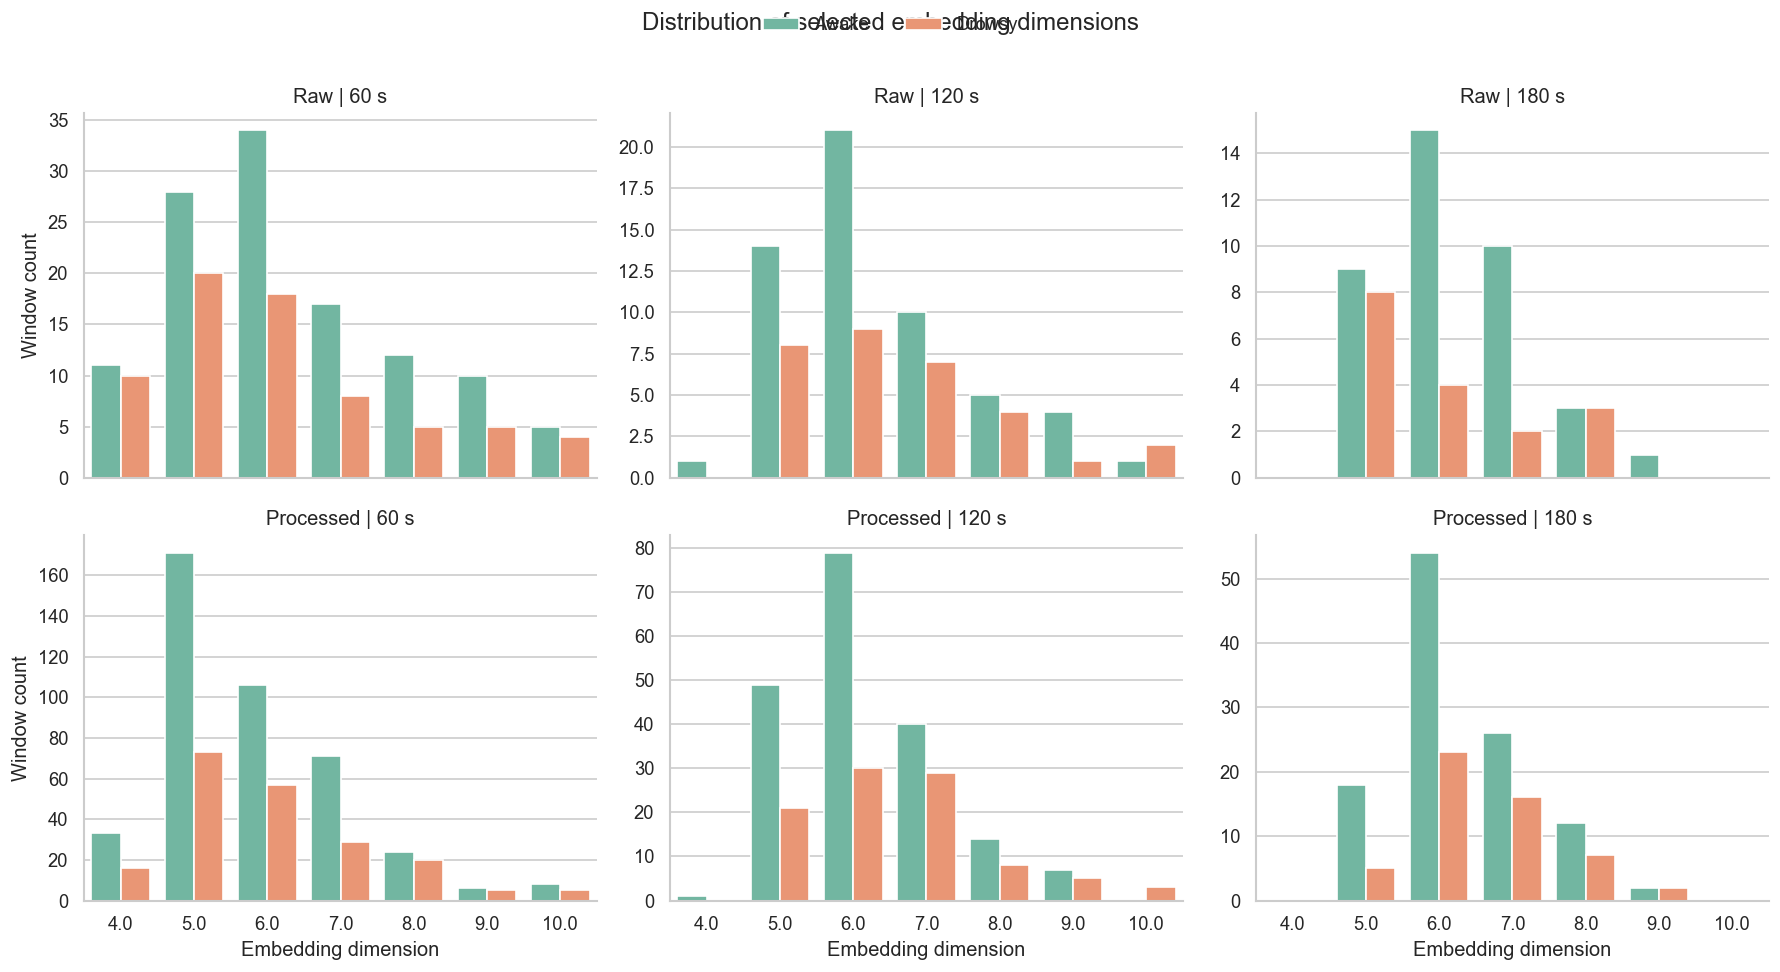

In [11]:
figure, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for row_index, representation in enumerate(("Raw", "Processed")):
    for column_index, window_size in enumerate(WINDOW_SIZES):
        axis = axes[row_index, column_index]
        subset = found_results[
            (found_results["representation"] == representation)
            & (found_results["window_size_s"] == window_size)
        ]
        sns.countplot(
            data=subset,
            x="selected_m",
            hue="label",
            palette="Set2",
            ax=axis,
        )
        axis.set_title(f"{representation} | {window_size} s")
        axis.set_xlabel("Embedding dimension")
        axis.set_ylabel("Window count" if column_index == 0 else "")
        if not (row_index == 0 and column_index == 0):
            axis.get_legend().remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
axes[0, 0].get_legend().remove()
figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
)
figure.suptitle("Distribution of selected embedding dimensions", y=1.01)
figure.tight_layout()
plt.show()


## Tổng hợp cấp phiên

Phiên là observational unit chính cho các so sánh Awake–Drowsy.


In [12]:
SESSION_KEYS = [
    "session",
    "window_size_s",
    "label",
    "representation",
]
session_summary = (
    fnn_results
    .groupby(SESSION_KEYS, observed=True)
    .agg(
        n_windows=("m_found", "size"),
        n_m_found=("m_found", "sum"),
        median_m=("selected_m", "median"),
        iqr_m=("selected_m", iqr),
        mode_m=("selected_m", first_mode),
    )
    .reset_index()
)
session_summary["m_found_rate_pct"] = (
    100.0
    * session_summary["n_m_found"]
    / session_summary["n_windows"]
)
session_summary.to_csv(SESSION_SUMMARY_PATH, index=False)

display(session_summary.head(12))
print(f"Session-level rows: {len(session_summary)}")
print(f"Saved: {SESSION_SUMMARY_PATH}")


,session,window_size_s,label,representation,n_windows,n_m_found,median_m,iqr_m,mode_m,m_found_rate_pct
0,sample_1.csv,60,Awake,Processed,24,24,5.0,0.00,5.0,100.000000
1,sample_1.csv,60,Awake,Raw,14,14,6.0,0.75,6.0,100.000000
2,sample_1.csv,60,Drowsy,Processed,7,7,5.0,1.00,5.0,100.000000
3,sample_1.csv,60,Drowsy,Raw,3,3,5.0,0.50,5.0,100.000000
4,sample_1.csv,120,Awake,Processed,11,11,5.0,1.00,5.0,100.000000
5,sample_1.csv,120,Awake,Raw,8,8,6.5,1.25,7.0,100.000000
6,sample_1.csv,120,Drowsy,Processed,1,1,5.0,0.00,5.0,100.000000
7,sample_1.csv,180,Awake,Processed,6,6,6.0,0.75,6.0,100.000000
8,sample_1.csv,180,Awake,Raw,5,5,7.0,1.00,7.0,100.000000
9,sample_1.csv,180,Drowsy,Processed,1,1,5.0,0.00,5.0,100.000000


Session-level rows: 238
Saved: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\results\fnn\fnn_session_summary.csv


## Awake so với Drowsy

So sánh ghép cặp sử dụng trung vị `m` của mỗi phiên, tách riêng theo kích thước
cửa sổ và dạng dữ liệu.


In [13]:
state_pairs = (
    session_summary
    .pivot_table(
        index=["session", "window_size_s", "representation"],
        columns="label",
        values="median_m",
    )
    .dropna(subset=["Awake", "Drowsy"])
    .reset_index()
)
state_pairs["delta_m"] = state_pairs["Drowsy"] - state_pairs["Awake"]

state_summary = (
    state_pairs
    .groupby(["window_size_s", "representation"], observed=True)
    ["delta_m"]
    .agg(
        paired_n="size",
        median_delta="median",
        iqr_delta=iqr,
        pct_higher=lambda values: 100.0 * (values > 0).mean(),
        pct_equal=lambda values: 100.0 * (values == 0).mean(),
        pct_lower=lambda values: 100.0 * (values < 0).mean(),
    )
    .reset_index()
)
display(state_summary)


,window_size_s,representation,paired_n,median_delta,iqr_delta,pct_higher,pct_equal,pct_lower
0,60,Processed,20,0.0,1.125,40.000000,30.000000,30.000000
1,60,Raw,18,-0.5,1.875,38.888889,5.555556,55.555556
2,120,Processed,20,0.0,1.000,45.000000,35.000000,20.000000
3,120,Raw,12,0.0,1.625,41.666667,16.666667,41.666667
4,180,Processed,17,0.0,1.500,47.058824,23.529412,29.411765
5,180,Raw,9,0.0,1.000,22.222222,33.333333,44.444444


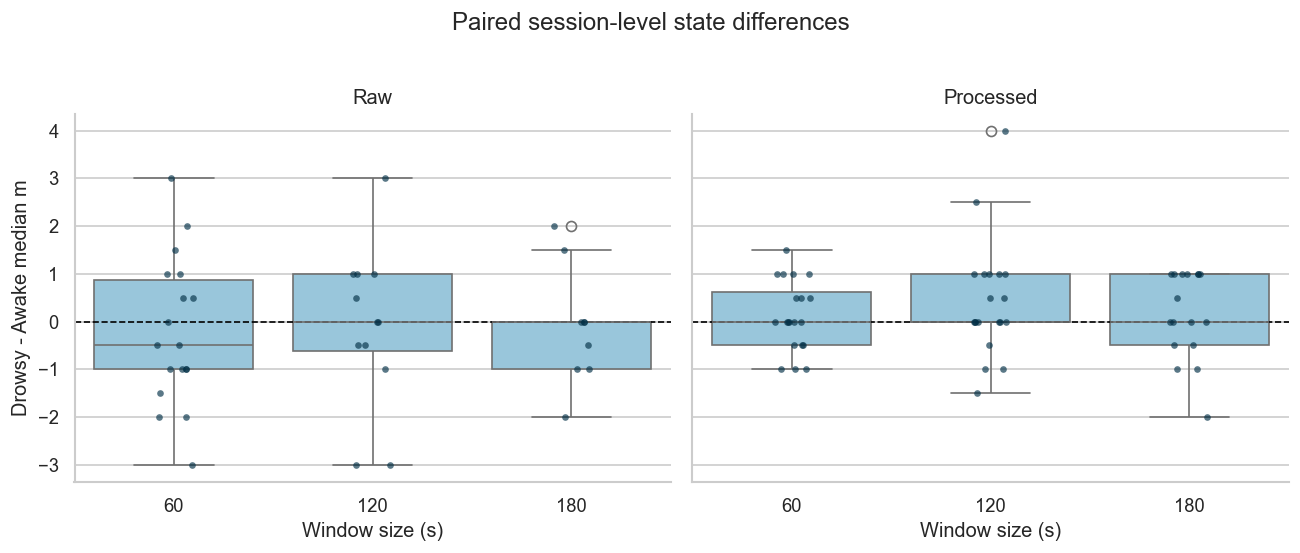

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for axis, representation in zip(axes, ("Raw", "Processed")):
    subset = state_pairs[
        state_pairs["representation"] == representation
    ]
    sns.boxplot(
        data=subset,
        x="window_size_s",
        y="delta_m",
        color="#8ecae6",
        ax=axis,
    )
    sns.stripplot(
        data=subset,
        x="window_size_s",
        y="delta_m",
        color="#023047",
        alpha=0.65,
        size=4,
        ax=axis,
    )
    axis.axhline(0.0, color="black", linewidth=1, linestyle="--")
    axis.set_title(representation)
    axis.set_xlabel("Window size (s)")
    axis.set_ylabel("Drowsy - Awake median m" if axis is axes[0] else "")

figure.suptitle("Paired session-level state differences", y=1.02)
figure.tight_layout()
plt.show()


## Raw so với Processed

Chỉ ghép các analysis window có kết quả FNN hợp lệ ở cả hai dạng dữ liệu.


In [15]:
PAIR_KEYS = ["session", "window_id", "window_size_s", "label"]
raw_results = fnn_results[fnn_results["representation"] == "Raw"]
processed_results = fnn_results[
    fnn_results["representation"] == "Processed"
]
representation_pairs = raw_results.merge(
    processed_results,
    on=PAIR_KEYS,
    suffixes=("_raw", "_processed"),
    validate="one_to_one",
)
representation_pairs = representation_pairs[
    representation_pairs["m_found_raw"]
    & representation_pairs["m_found_processed"]
].copy()
representation_pairs["delta_m"] = (
    representation_pairs["selected_m_processed"]
    - representation_pairs["selected_m_raw"]
)

representation_summary = (
    representation_pairs
    .groupby(["window_size_s", "label"], observed=True)
    .agg(
        n_pairs=("delta_m", "size"),
        median_delta=("delta_m", "median"),
        iqr_delta=("delta_m", iqr),
        exact_agreement_pct=(
            "delta_m",
            lambda values: 100.0 * (values == 0).mean(),
        ),
        within_1_dimension_pct=(
            "delta_m",
            lambda values: 100.0 * (values.abs() <= 1).mean(),
        ),
    )
    .reset_index()
)
display(representation_summary)


,window_size_s,label,n_pairs,median_delta,iqr_delta,exact_agreement_pct,within_1_dimension_pct
0,60,Awake,89,-1.0,3.00,15.730337,61.797753
1,60,Drowsy,45,0.0,2.00,31.111111,57.777778
2,120,Awake,44,0.0,3.00,25.000000,68.181818
3,120,Drowsy,20,0.0,3.00,25.000000,65.000000
4,180,Awake,28,0.0,2.00,21.428571,71.428571
5,180,Drowsy,12,0.0,1.25,33.333333,66.666667


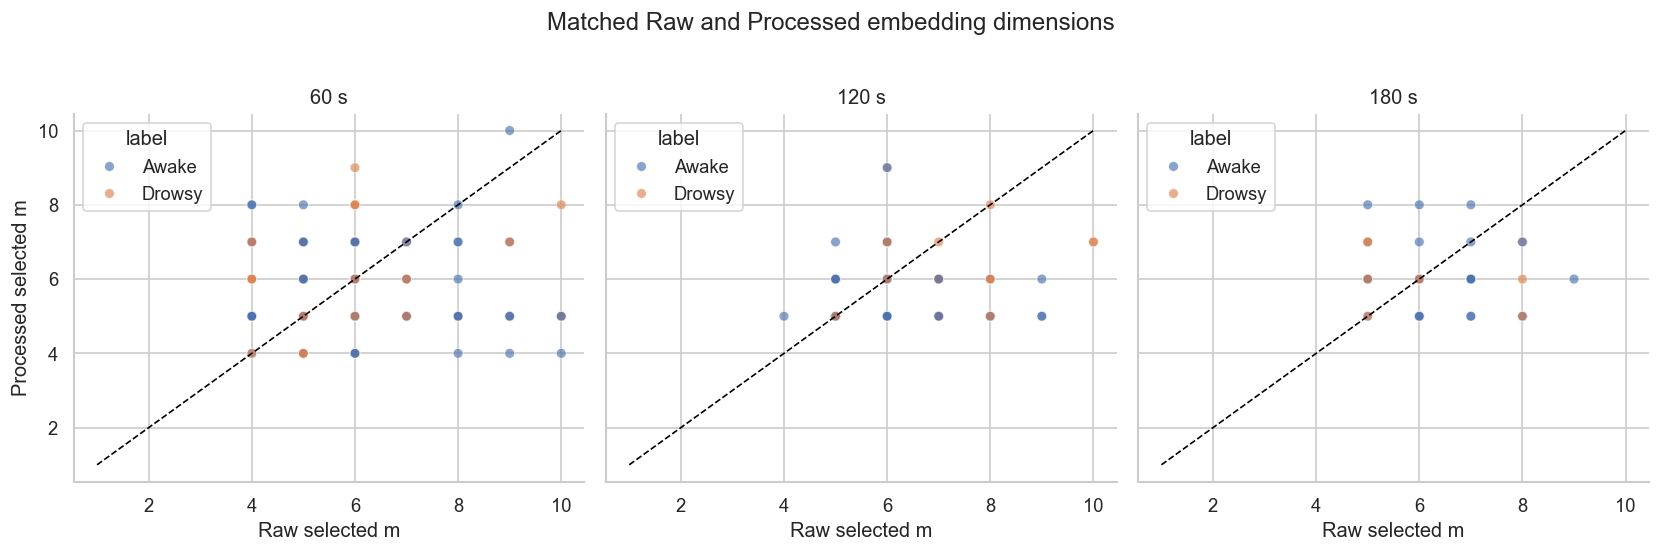

In [16]:
figure, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
for axis, window_size in zip(axes, WINDOW_SIZES):
    subset = representation_pairs[
        representation_pairs["window_size_s"] == window_size
    ]
    sns.scatterplot(
        data=subset,
        x="selected_m_raw",
        y="selected_m_processed",
        hue="label",
        alpha=0.65,
        s=34,
        ax=axis,
    )
    axis.plot(
        [1, MAX_M],
        [1, MAX_M],
        color="black",
        linestyle="--",
        linewidth=1,
    )
    axis.set_title(f"{window_size} s")
    axis.set_xlabel("Raw selected m")
    axis.set_ylabel(
        "Processed selected m" if window_size == 60 else ""
    )

figure.suptitle("Matched Raw and Processed embedding dimensions", y=1.02)
figure.tight_layout()
plt.show()


## Độ ổn định theo kích thước cửa sổ

So sánh được thực hiện trên trung vị cấp phiên cho cùng trạng thái và dạng dữ
liệu.


In [17]:
size_wide = session_summary.pivot_table(
    index=["session", "label", "representation"],
    columns="window_size_s",
    values="median_m",
)

stability_rows = []
for first_size, second_size in ((60, 120), (60, 180), (120, 180)):
    paired = size_wide[[first_size, second_size]].dropna().reset_index()
    for (label, representation), group in paired.groupby(
        ["label", "representation"],
        observed=True,
    ):
        difference = (group[first_size] - group[second_size]).abs()
        stability_rows.append({
            "comparison": f"{first_size} vs {second_size}",
            "label": label,
            "representation": representation,
            "paired_n": len(group),
            "median_abs_difference": difference.median(),
            "iqr_abs_difference": iqr(difference),
            "exact_agreement_pct": 100.0 * (difference == 0).mean(),
            "within_1_dimension_pct": 100.0 * (difference <= 1).mean(),
            "spearman_correlation": safe_spearman(
                group[first_size],
                group[second_size],
            ),
        })

window_stability = pd.DataFrame(stability_rows)
display(window_stability)


,comparison,label,representation,paired_n,median_abs_difference,iqr_abs_difference,exact_agreement_pct,within_1_dimension_pct,spearman_correlation
0,60 vs 120,Awake,Processed,20,0.00,1.000,55.000000,90.000000,0.652625
1,60 vs 120,Awake,Raw,14,0.50,1.625,28.571429,71.428571,0.631735
2,60 vs 120,Drowsy,Processed,20,0.50,1.000,45.000000,80.000000,0.364971
3,60 vs 120,Drowsy,Raw,16,1.00,1.125,18.750000,56.250000,0.123451
4,60 vs 180,Awake,Processed,20,1.00,0.625,25.000000,90.000000,0.713993
5,60 vs 180,Awake,Raw,14,0.75,1.000,35.714286,85.714286,0.605672
6,60 vs 180,Drowsy,Processed,17,1.00,0.500,17.647059,88.235294,0.592909
7,60 vs 180,Drowsy,Raw,10,0.50,1.000,40.000000,90.000000,0.693260
8,120 vs 180,Awake,Processed,20,0.25,1.000,50.000000,95.000000,0.591036
9,120 vs 180,Awake,Raw,12,0.50,0.625,25.000000,83.333333,0.706568


## Diagnostic FNN curves

Các cửa sổ được chọn có hệ thống để đại diện cho `m` thấp, trung vị, cao,
failure, khác biệt Raw–Processed và khác biệt Awake–Drowsy.


,selection,session,window_id,window_size_s,label,representation,selected_m
0,Low selected m,sample_1.csv,24,60,Drowsy,Processed,4.0
1,Median selected m,sample_25.csv,2,180,Awake,Processed,6.0
2,High selected m,sample_10.csv,16,120,Drowsy,Raw,10.0
3,selected_m=None,sample_4.csv,1,60,Awake,Raw,NaN
4,Raw-Processed pair: Raw,sample_15.csv,12,60,Awake,Raw,10.0
5,Raw-Processed pair: Processed,sample_15.csv,12,60,Awake,Processed,4.0
6,Awake-Drowsy pair: Awake,sample_15.csv,1,120,Awake,Processed,6.0
7,Awake-Drowsy pair: Drowsy,sample_15.csv,13,120,Drowsy,Processed,10.0


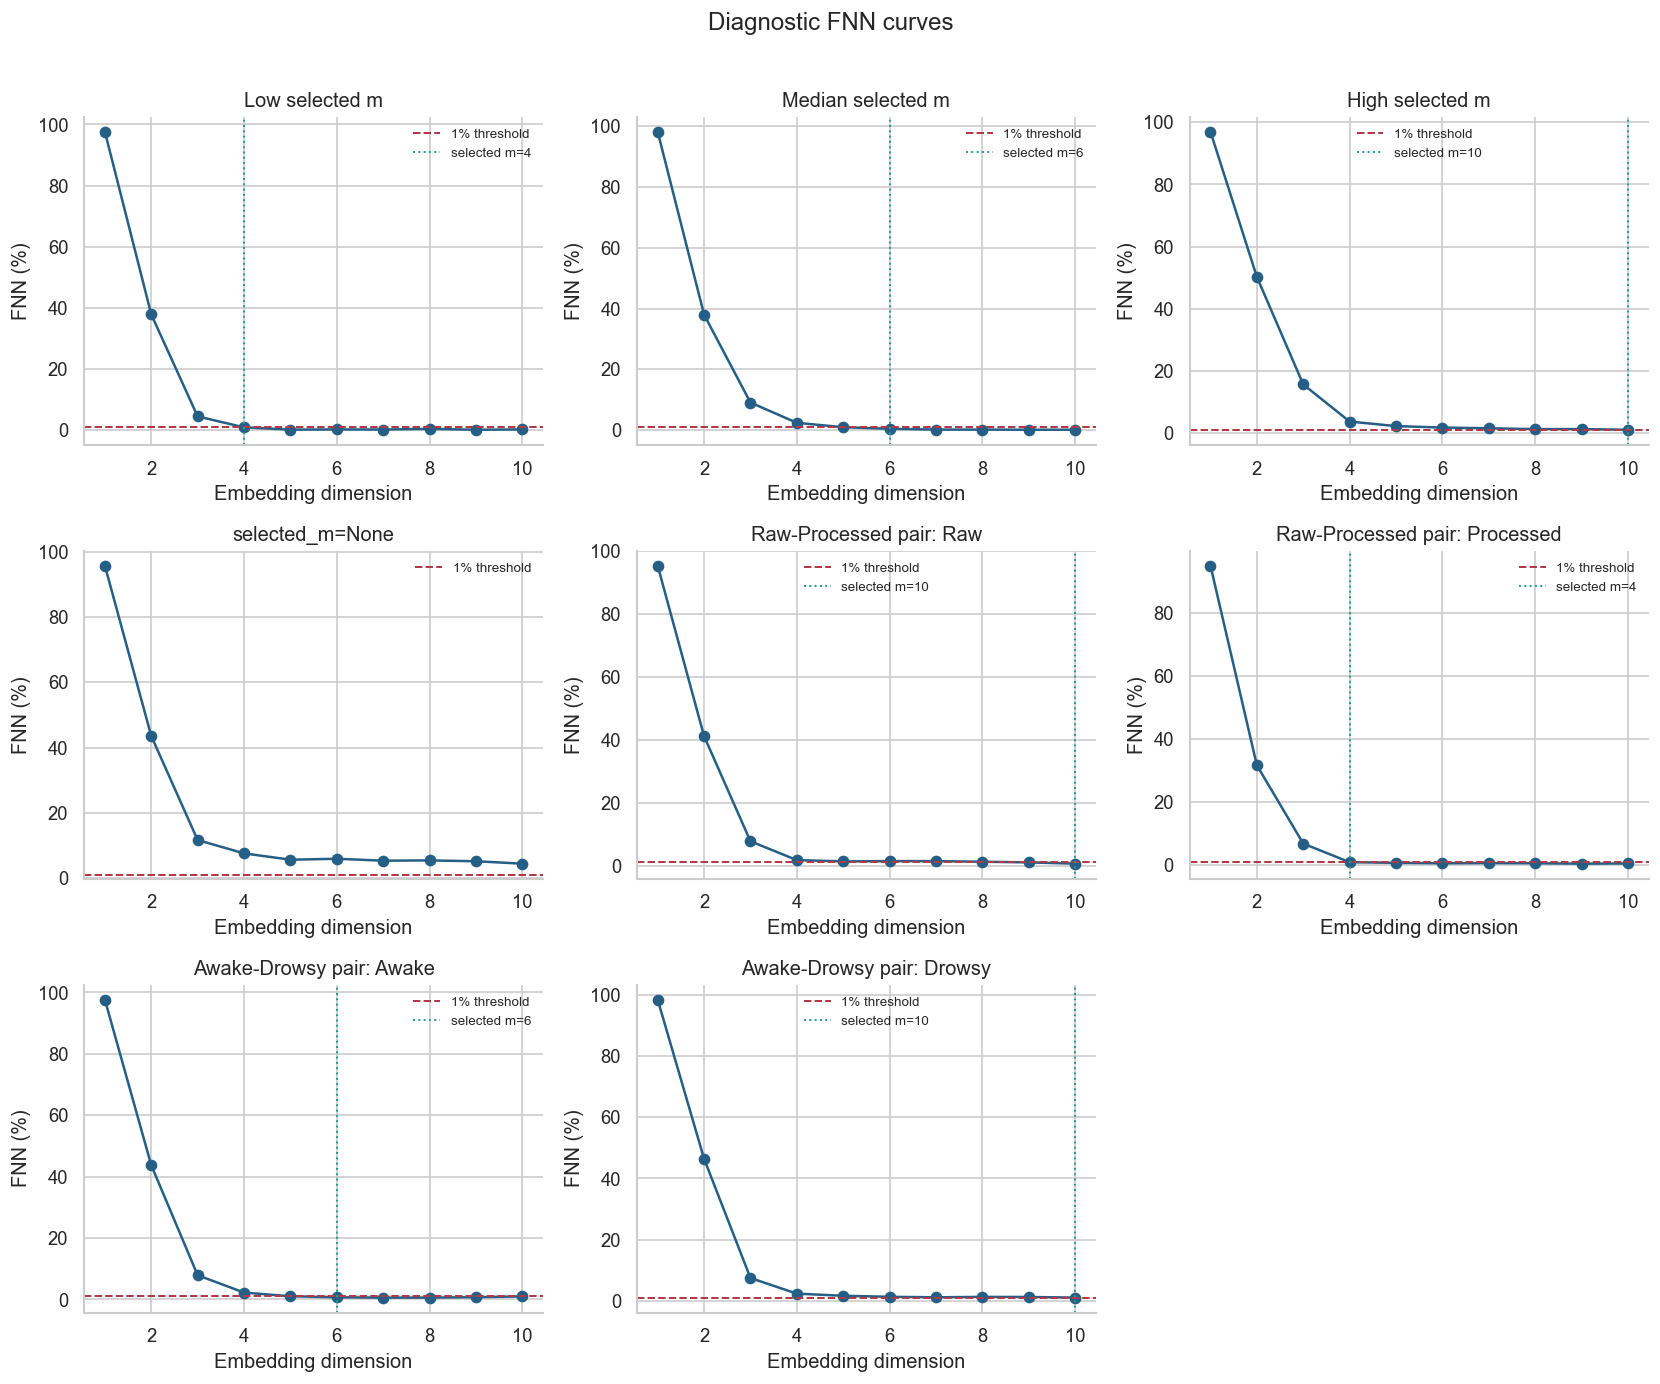

In [18]:
DIAGNOSTIC_KEYS = [
    "session",
    "window_id",
    "window_size_s",
    "label",
    "representation",
]


def append_diagnostic(rows, selection, row):
    "Append one diagnostic row unless it is duplicated."
    if row is None:
        return
    record = row.to_dict()
    key = tuple(record[name] for name in DIAGNOSTIC_KEYS)
    existing = {
        tuple(item[name] for name in DIAGNOSTIC_KEYS)
        for item in rows
    }
    if key not in existing:
        record["selection"] = selection
        rows.append(record)


diagnostic_rows = []
ordered_found = found_results.sort_values("selected_m")
append_diagnostic(
    diagnostic_rows,
    "Low selected m",
    ordered_found.iloc[0],
)
median_m = ordered_found["selected_m"].median()
median_index = (
    ordered_found["selected_m"] - median_m
).abs().idxmin()
append_diagnostic(
    diagnostic_rows,
    "Median selected m",
    ordered_found.loc[median_index],
)
append_diagnostic(
    diagnostic_rows,
    "High selected m",
    ordered_found.iloc[-1],
)

missing_m = fnn_results[~fnn_results["m_found"]]
append_diagnostic(
    diagnostic_rows,
    "selected_m=None",
    None if missing_m.empty else missing_m.iloc[0],
)

if not representation_pairs.empty:
    pair = representation_pairs.loc[
        representation_pairs["delta_m"].abs().idxmax()
    ]
    pair_filter = (
        (fnn_results["session"] == pair["session"])
        & (fnn_results["window_id"] == pair["window_id"])
        & (fnn_results["window_size_s"] == pair["window_size_s"])
        & (fnn_results["label"] == pair["label"])
    )
    for representation in ("Raw", "Processed"):
        row = fnn_results[
            pair_filter
            & (fnn_results["representation"] == representation)
        ].iloc[0]
        append_diagnostic(
            diagnostic_rows,
            f"Raw-Processed pair: {representation}",
            row,
        )

if not state_pairs.empty:
    state_pair = state_pairs.loc[state_pairs["delta_m"].abs().idxmax()]
    for label in ("Awake", "Drowsy"):
        state_filter = (
            (fnn_results["session"] == state_pair["session"])
            & (
                fnn_results["window_size_s"]
                == state_pair["window_size_s"]
            )
            & (
                fnn_results["representation"]
                == state_pair["representation"]
            )
            & (fnn_results["label"] == label)
            & fnn_results["m_found"]
        )
        candidates = fnn_results[state_filter]
        target = state_pair[label]
        if not candidates.empty:
            row_index = (
                candidates["selected_m"] - target
            ).abs().idxmin()
            append_diagnostic(
                diagnostic_rows,
                f"Awake-Drowsy pair: {label}",
                candidates.loc[row_index],
            )

diagnostic_selection = pd.DataFrame(diagnostic_rows)
display(diagnostic_selection[["selection", *DIAGNOSTIC_KEYS, "selected_m"]])

plot_rows = int(np.ceil(len(diagnostic_selection) / 3))
figure, axes = plt.subplots(
    plot_rows,
    3,
    figsize=(14, 3.8 * plot_rows),
    squeeze=False,
)
for axis, (_, row) in zip(axes.flat, diagnostic_selection.iterrows()):
    curve_filter = np.ones(len(fnn_curves), dtype=bool)
    for key in DIAGNOSTIC_KEYS:
        curve_filter &= fnn_curves[key].eq(row[key]).to_numpy()
    curve = fnn_curves[curve_filter]
    axis.plot(
        curve["dimension"],
        curve["fnn_percent"],
        marker="o",
        color="#255f85",
    )
    axis.axhline(
        FNN_THRESHOLD,
        color="#b23a48",
        linestyle="--",
        linewidth=1.2,
        label="1% threshold",
    )
    if row["m_found"]:
        axis.axvline(
            row["selected_m"],
            color="#2a9d8f",
            linestyle=":",
            linewidth=1.2,
            label=f"selected m={int(row['selected_m'])}",
        )
    axis.set_title(row["selection"])
    axis.set_xlabel("Embedding dimension")
    axis.set_ylabel("FNN (%)")
    axis.legend(frameon=False, fontsize=8)

for axis in axes.flat[len(diagnostic_selection):]:
    axis.remove()

figure.suptitle("Diagnostic FNN curves", y=1.01)
figure.tight_layout()
plt.show()
